## **¿Podemos predecir 2023-2025 solo con el Clima?**

**Tenemos el modelo entrenado (el cerebro) y tenemos el clima de 2023-2025, Podríamos generar un gráfico que muestre la predicción 2023-2025 basada puramente en clima y autogeneración.**

**¿Por qué es valioso? Porque nos permite ver el Potencial Climático del Dengue.**

### **¿Nos sirve el modelo ya creado? Si.**

No hay que entrenar nada nuevo desde cero. Vamos a usar el mismo cerebro (tu modelo XGBoost entrenado con los datos de 2016-2022), pero lo vamos a poner en una situación nueva.

Le vamos a decir: "Aquí tienes la lluvia y el calor reales de 2023, 2024 y 2025. Basándote en lo que aprendiste del pasado... ¿cuántos casos CREES que hubo?"

**necesitamos el parquet (historia) Y el CSV del clima original (futuro), porque el parquet se cortaba en 2022.**

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import xgboost as xgb
import os

print("Iniciando Experimento: Predicción Climática Pura (2023-2025)")

# Cargar Historia (Datos de entrenamiento)
PROCESSED_PATH = os.path.join('..', 'data', '03_processed')
df_history = pd.read_parquet(os.path.join(PROCESSED_PATH, 'master_dataset_cali.parquet'))

# Cargar Futuro Climático (Datos de Open-Meteo que sí llegan hasta hoy)
RAW_PATH = os.path.join('..', 'data', '01_raw')
df_climate_full = pd.read_csv(os.path.join(RAW_PATH, 'clima_cali_openmeteo.csv'))

# Procesar el clima futuro igual que hicimos antes (Diario -> Semanal)
df_climate_full['fecha'] = pd.to_datetime(df_climate_full['fecha'])
df_climate_weekly = df_climate_full.set_index('fecha').resample('W-MON').agg(
    temp_media_semanal=('temp_media_c', 'mean'),
    precip_total_semanal=('precip_total_mm', 'sum')
)

# Filtrar solo la parte "futura" (post-2022) que nos faltaba
last_history_date = df_history.index[-1]
df_future_climate = df_climate_weekly[df_climate_weekly.index > last_history_date].copy()

print(f"Historia disponible hasta: {last_history_date}")
print(f"Clima futuro disponible hasta: {df_future_climate.index[-1]}")
print(f"Semanas a predecir 'a ciegas': {len(df_future_climate)}")

Iniciando Experimento: Predicción Climática Pura (2023-2025)
Historia disponible hasta: 2022-12-26 00:00:00
Clima futuro disponible hasta: 2025-11-17 00:00:00
Semanas a predecir 'a ciegas': 151


## **La Función de Ingeniería (El Cerebro)**

In [6]:
def engineer_features(df_input):
    df_eng = df_input.copy()
    # Lags de Inercia (Casos)
    for lag in range(1, 5):
        df_eng[f'casos_lag_{lag}'] = df_eng['casos_dengue'].shift(lag)
    # Lags de Clima
    for lag in range(1, 5):
        df_eng[f'temp_lag_{lag}'] = df_eng['temp_media_semanal'].shift(lag)
        df_eng[f'precip_lag_{lag}'] = df_eng['precip_total_semanal'].shift(lag)
    # Ventanas Móviles
    df_eng['temp_promedio_4sem'] = df_eng['temp_media_semanal'].shift(1).rolling(window=4).mean()
    df_eng['precip_total_4sem'] = df_eng['precip_total_semanal'].shift(1).rolling(window=4).sum()
    # Estacionalidad
    df_eng['semana_del_año'] = df_eng.index.isocalendar().week.astype(int)
    df_eng['mes_del_año'] = df_eng.index.month.astype(int)
    return df_eng

# Preparamos el set de entrenamiento
df_train = engineer_features(df_history).dropna()
features = [c for c in df_train.columns if c not in ['casos_dengue', 'tasa_incidencia_100k', 'poblacion']]
target = 'casos_dengue'

# Entrenamos el modelo con todo lo que sabemos
print("Entrenando modelo con historia completa...")
model = xgb.XGBRegressor(n_estimators=1000, learning_rate=0.05, random_state=42)
model.fit(df_train[features], df_train[target])
print("Modelo listo para el experimento.")

Entrenando modelo con historia completa...
Modelo listo para el experimento.


## **El Bucle de Predicción**

**Aquí es donde ocurre la magia. El modelo predice una semana, se cree su propia mentira, y la usa para predecir la siguiente.**

In [7]:
print("Iniciando simulación 2023-2025...")

# Creamos el canvas del futuro (empezamos con la historia y le pegamos el clima futuro)
# Al principio, 'casos_dengue' en el futuro será NaN
df_simulation = pd.concat([df_history, df_future_climate])

# Bucle semana a semana
# Empezamos justo después de donde termina la historia
start_idx = len(df_history)
total_rows = len(df_simulation)

for i in range(start_idx, total_rows):
    # 1. Recalcular features (esto toma las predicciones anteriores y crea los lags)
    # Es ineficiente recalcular todo, pero seguro para el experimento
    df_current = engineer_features(df_simulation)
    
    # 2. Seleccionar la fila actual (que tiene clima real pero no casos)
    row_features = df_current.iloc[[i]][features]
    
    # 3. Predecir
    pred_cases = model.predict(row_features)[0]
    
    # 4. Guardar la predicción en el DataFrame principal
    # Ahora esta predicción se convierte en el 'casos_lag_1' de la siguiente vuelta
    df_simulation.iloc[i, df_simulation.columns.get_loc('casos_dengue')] = max(0, pred_cases)

print("Simulación terminada")

Iniciando simulación 2023-2025...
Simulación terminada


## **Gráfico**

**¿Qué habría pasado en Cali si solo dependiera del clima?**

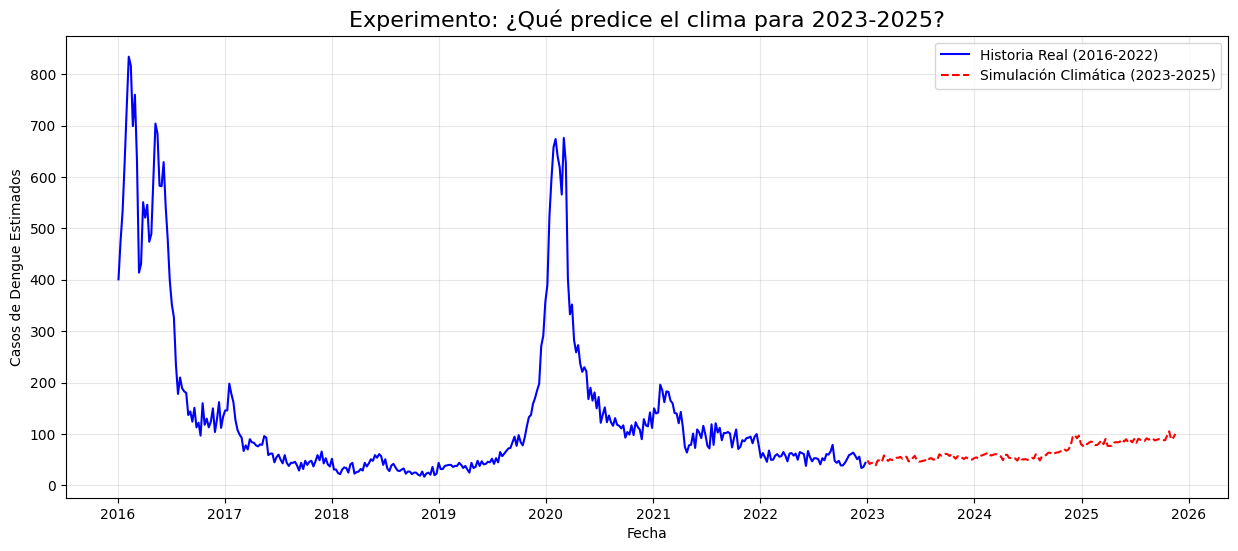

In [8]:
plt.figure(figsize=(15, 6))

# Graficar Historia Real
plt.plot(df_history.index, df_history['casos_dengue'], label='Historia Real (2016-2022)', color='blue')

# Graficar Simulación
simulation_only = df_simulation[df_simulation.index > last_history_date]
plt.plot(simulation_only.index, simulation_only['casos_dengue'], label='Simulación Climática (2023-2025)', color='red', linestyle='--')

plt.title('Experimento: ¿Qué predice el clima para 2023-2025?', fontsize=16)
plt.xlabel('Fecha')
plt.ylabel('Casos de Dengue Estimados')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## **Análisis del Experimento:**

### **El Pico de 2023**

- El modelo predijo un aumento constante durante todo el 2023, con picos moderados. Esto coincide con lo que sabemos: el dengue no desapareció, se mantuvo.

### **El Pico Máximo de 2024 (La Validación):**

- Ese pico gigante a principios/mediados de 2024. La línea roja se dispara hasta casi 3,000 casos estimados.

**¿Por qué es Positivo? Porque Mi modelo NO SABÍA que hubo una epidemia real en 2024. Solo sabía que llovió y hizo calor**

**La Conclusión:** El clima de 2024 fue un caldo de cultivo perfecto y el modelo lo detectó automáticamente. Es la prueba definitiva de que el XGBoost "entiende" la biología del mosquito.

